The goal of this Jupyter Notebook is to plot the signifcant coefficient of the regdhfe by market for each output variable.

In [15]:
import pandas as pd

# Import raw csv files

df_won_1 = pd.read_csv('/Users/dvacchini/Library/CloudStorage/Dropbox/Projects_Brazilian_data/Dario_vacchini/data/raw/market/reg_won_t_minus_1_1_750_market.csv')
df_won_2 = pd.read_csv('/Users/dvacchini/Library/CloudStorage/Dropbox/Projects_Brazilian_data/Dario_vacchini/data/raw/market/reg_won_t_minus_1500_3500_market.csv')

df_cumprof_1 = pd.read_csv('/Users/dvacchini/Library/CloudStorage/Dropbox/Projects_Brazilian_data/Dario_vacchini/data/raw/market/reg_cumprof_won_120_std_1_750_market.csv')
df_cumprof_2 = pd.read_csv('/Users/dvacchini/Library/CloudStorage/Dropbox/Projects_Brazilian_data/Dario_vacchini/data/raw/market/reg_cumprof_won_120_std_1500_3500_market.csv')

df_last_1 = pd.read_csv('/Users/dvacchini/Library/CloudStorage/Dropbox/Projects_Brazilian_data/Dario_vacchini/data/raw/market/reg_last_bid_1_750_market.csv')
df_last_2 = pd.read_csv('/Users/dvacchini/Library/CloudStorage/Dropbox/Projects_Brazilian_data/Dario_vacchini/data/raw/market/reg_last_bid_1500_3500_market.csv')

df_90won_1 = pd.read_csv('/Users/dvacchini/Library/CloudStorage/Dropbox/Projects_Brazilian_data/Dario_vacchini/data/raw/market/reg_share_won90_1_750_market.csv')
df_90won_2 = pd.read_csv('/Users/dvacchini/Library/CloudStorage/Dropbox/Projects_Brazilian_data/Dario_vacchini/data/raw/market/reg_share_won90_1500_3500_market.csv')

df_age_1 = pd.read_csv('/Users/dvacchini/Library/CloudStorage/Dropbox/Projects_Brazilian_data/Dario_vacchini/data/raw/market/reg_age_1_750_market.csv')
df_age_2 = pd.read_csv('/Users/dvacchini/Library/CloudStorage/Dropbox/Projects_Brazilian_data/Dario_vacchini/data/raw/market/reg_age_3500_7581_market.csv')

df_lim_firm_1 = pd.read_csv('/Users/dvacchini/Library/CloudStorage/Dropbox/Projects_Brazilian_data/Dario_vacchini/data/raw/market/reg_limited_firm_1_750_market.csv')
df_lim_firm_2 = pd.read_csv('/Users/dvacchini/Library/CloudStorage/Dropbox/Projects_Brazilian_data/Dario_vacchini/data/raw/market/reg_limited_firm_3500_7581_market.csv')

df_sec_bid_1 = pd.read_csv('/Users/dvacchini/Library/CloudStorage/Dropbox/Projects_Brazilian_data/Dario_vacchini/data/raw/market/reg_second_t_minus_1_1_750_market.csv')
df_sec_bid_2 = pd.read_csv('/Users/dvacchini/Library/CloudStorage/Dropbox/Projects_Brazilian_data/Dario_vacchini/data/raw/market/reg_second_t_minus_1_3500_7581_market.csv')

In [16]:
# Merge csv files and drop duplicates

df_won = pd.concat([df_won_1, df_won_2], ignore_index=True).drop_duplicates()
df_cumprof = pd.concat([df_cumprof_1, df_cumprof_2], ignore_index=True).drop_duplicates()
df_last = pd.concat([df_last_1, df_last_2], ignore_index=True).drop_duplicates()
df_90won = pd.concat([df_90won_1, df_90won_2], ignore_index=True).drop_duplicates()
df_age = pd.concat([df_age_1, df_age_2], ignore_index=True).drop_duplicates()
df_lim_firm = pd.concat([df_lim_firm_1, df_lim_firm_2], ignore_index=True).drop_duplicates()
df_sec_bid = pd.concat([df_sec_bid_1, df_sec_bid_2], ignore_index=True).drop_duplicates()

df_won = df_won.loc[df_won['Variable'] != '1.flagvencedor#c.MV']
df_cumprof = df_cumprof.loc[df_cumprof['Variable'] != '1.flagvencedor#c.MV']
df_last = df_last.loc[df_last['Variable'] != '1.flagvencedor#c.MV']
df_90won = df_90won.loc[df_90won['Variable'] != '1.flagvencedor#c.MV']
df_age = df_age.loc[df_age['Variable'] != '1.flagvencedor#c.MV']
df_lim_firm = df_lim_firm.loc[df_lim_firm['Variable'] != '1.flagvencedor#c.MV']
df_sec_bid = df_sec_bid.loc[df_sec_bid['Variable'] != '1.flagvencedor#c.MV']


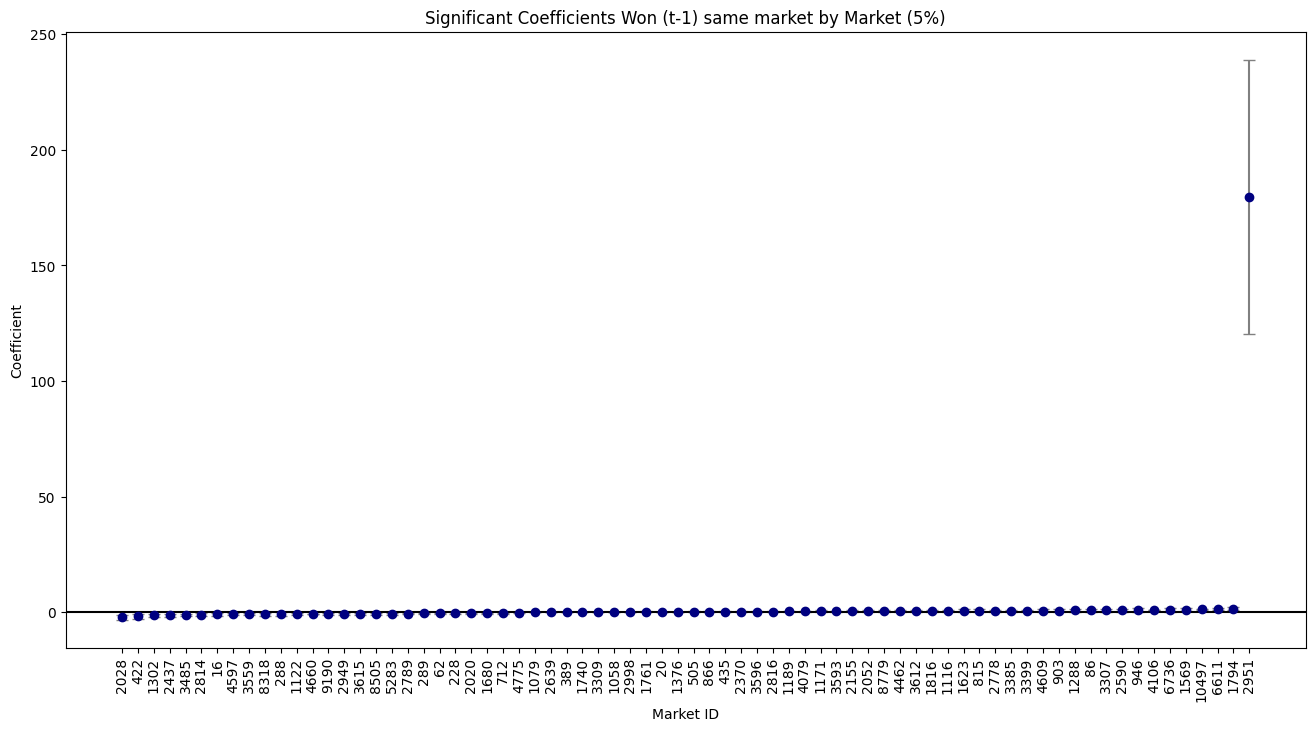

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

# Rename columns if needed to match the example
df_won = df_won.rename(columns={' Market Item': 'market_id', ' Coefficient': 'coefficient', ' Std. Error': 'std_error', ' Sig_1pct': 'sig_1pct', ' Sig_5pct': 'sig_5pct', ' Sig_10pct': 'sig_10pct'})
#df_won = df_won[df_won['market_id'] != 2951]

# Filter rows for significant coefficients (assuming 'sig_1pct' indicates significance)
df_significant = df_won[df_won['sig_5pct'] == 1]

# Sort the dataframe by 'coefficient' in ascending order
df_significant = df_significant.sort_values(by='coefficient', ascending=True)

# Calculate 95% confidence intervals
ci_95 = df_significant['std_error'] * 1.96

# Plot the coefficients with error bars
plt.figure(figsize=(16, 8))
plt.errorbar(range(len(df_significant)), df_significant['coefficient'],  # Use range of sorted index for evenly spaced ticks
             yerr=ci_95, fmt='o', color='navy', 
             ecolor='gray', capsize=4)

# Add a vertical line at y=0
plt.axhline(y=0, color='black')

# Labels and title
plt.xlabel('Market ID')
plt.ylabel('Coefficient')
plt.title('Significant Coefficients Won (t-1) same market by Market (5%)')

# Set the x-ticks to correspond to the sorted market_id values
plt.xticks(range(len(df_significant)), df_significant['market_id'].astype(str), rotation=90)

# Save the plot as a .pdf file (optional)
plt.savefig('/Users/dvacchini/Library/CloudStorage/Dropbox/Projects_Brazilian_data/Dario_vacchini/output/graphs/coef_sig_won_t_minus_1_market_5pct.pdf', bbox_inches='tight', dpi=300)

plt.show()


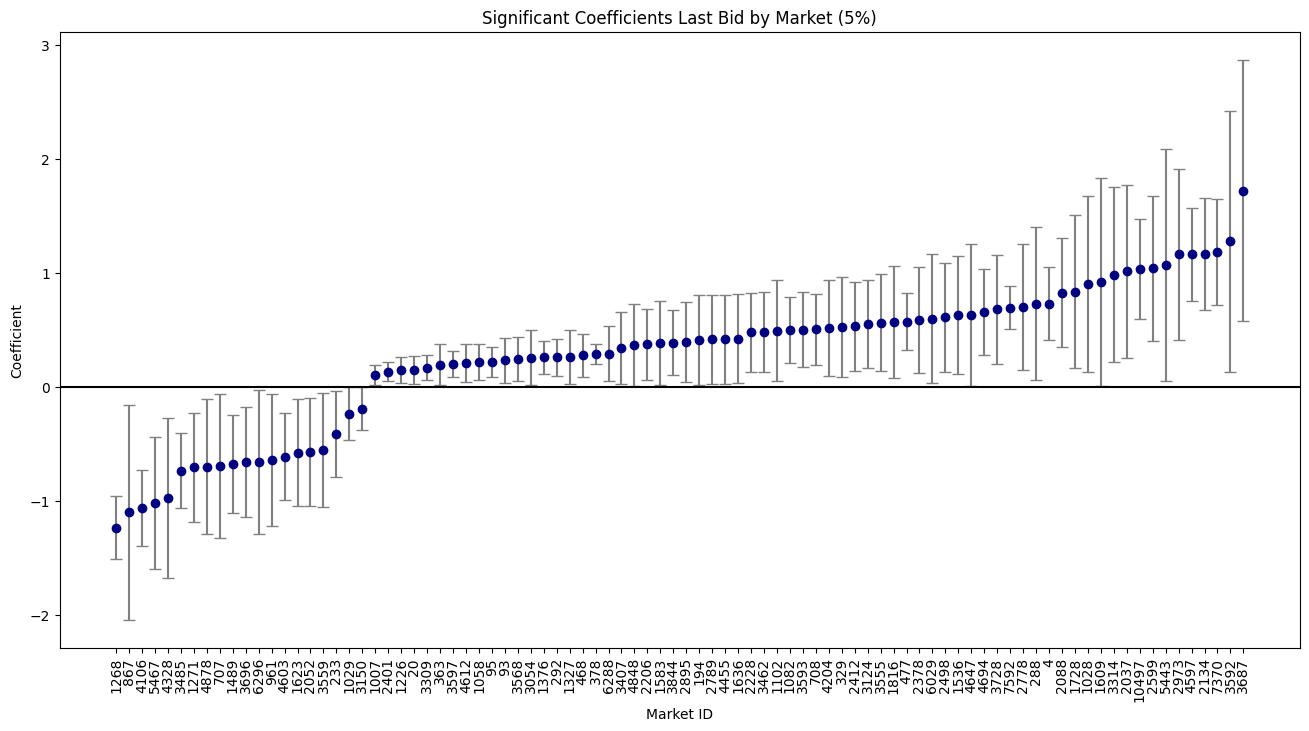

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

# Rename columns if needed to match the example
df_last = df_last.rename(columns={' Market Item': 'market_id', ' Coefficient': 'coefficient', ' Std. Error': 'std_error', ' Sig_1pct': 'sig_1pct', ' Sig_5pct': 'sig_5pct', ' Sig_10pct': 'sig_10pct'})
df_last = df_last[df_last['market_id'] != 4500]
df_last['market_id'] = df_last['market_id'].astype(int)

# Filter rows for significant coefficients (assuming 'sig_1pct' indicates significance)
df_significant_last = df_last[df_last['sig_5pct'] == 1]

# Sort the dataframe by 'coefficient' in ascending order
df_significant_last = df_significant_last.sort_values(by='coefficient', ascending=True)

# Calculate 95% confidence intervals
ci_95 = df_significant_last['std_error'] * 1.96

# Plot the coefficients with error bars
plt.figure(figsize=(16, 8))
plt.errorbar(range(len(df_significant_last)), df_significant_last['coefficient'],  # Use range of sorted index for evenly spaced ticks
             yerr=ci_95, fmt='o', color='navy', 
             ecolor='gray', capsize=4)

# Add a vertical line at y=0
plt.axhline(y=0, color='black')

# Labels and title
plt.xlabel('Market ID')
plt.ylabel('Coefficient')
plt.title('Significant Coefficients Last Bid by Market (5%)')

# Set the x-ticks to correspond to the sorted market_id values
plt.xticks(range(len(df_significant_last)), df_significant_last['market_id'].astype(int), rotation=90)

# Save the plot as a .pdf file (optional)
plt.savefig('/Users/dvacchini/Library/CloudStorage/Dropbox/Projects_Brazilian_data/Dario_vacchini/output/graphs/coef_sig_last_bid_market_5pct.pdf', bbox_inches='tight', dpi=300)

plt.show()

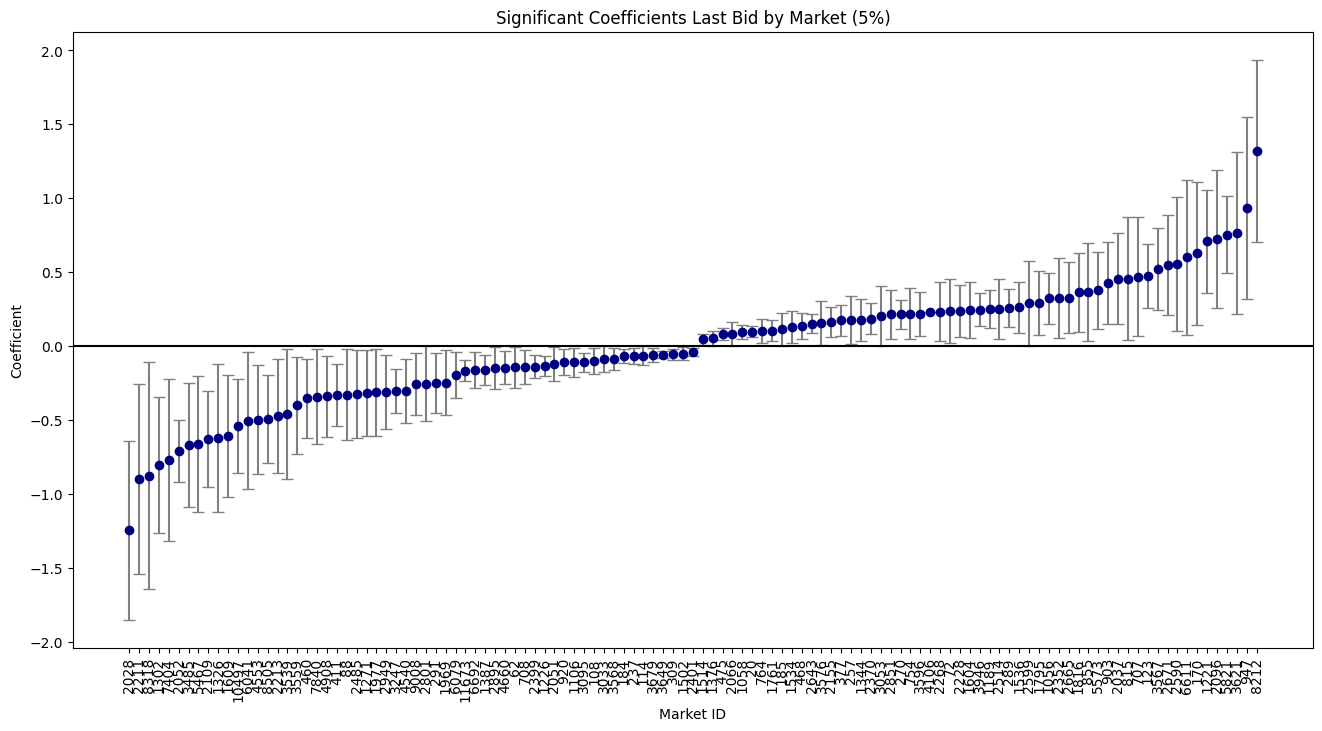

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

# Rename columns if needed to match the example
df_90won = df_90won.rename(columns={' Market Item': 'market_id', ' Coefficient': 'coefficient', ' Std. Error': 'std_error', ' Sig_1pct': 'sig_1pct', ' Sig_5pct': 'sig_5pct', ' Sig_10pct': 'sig_10pct'})
df_90won = df_90won[df_90won['market_id'] != 4500]
df_90won = df_90won[df_90won['market_id'] != 3457]
df_90won['market_id'] = df_90won['market_id'].astype(int)

# Filter rows for significant coefficients (assuming 'sig_1pct' indicates significance)
df_significant_90won = df_90won[df_90won['sig_5pct'] == 1]

# Sort the dataframe by 'coefficient' in ascending order
df_significant_90won = df_significant_90won.sort_values(by='coefficient', ascending=True)

# Calculate 95% confidence intervals
ci_95 = df_significant_90won['std_error'] * 1.96

# Plot the coefficients with error bars
plt.figure(figsize=(16, 8))
plt.errorbar(range(len(df_significant_90won)), df_significant_90won['coefficient'],  # Use range of sorted index for evenly spaced ticks
             yerr=ci_95, fmt='o', color='navy', 
             ecolor='gray', capsize=4)

# Add a vertical line at y=0
plt.axhline(y=0, color='black')

# Labels and title
plt.xlabel('Market ID')
plt.ylabel('Coefficient')
plt.title('Significant Coefficients Last Bid by Market (5%)')

# Set the x-ticks to correspond to the sorted market_id values
plt.xticks(range(len(df_significant_90won)), df_significant_90won['market_id'].astype(int), rotation=90)

# Save the plot as a .pdf file (optional)
plt.savefig('/Users/dvacchini/Library/CloudStorage/Dropbox/Projects_Brazilian_data/Dario_vacchini/output/graphs/coef_sig_90won_market_5pct.pdf', bbox_inches='tight', dpi=300)

plt.show()

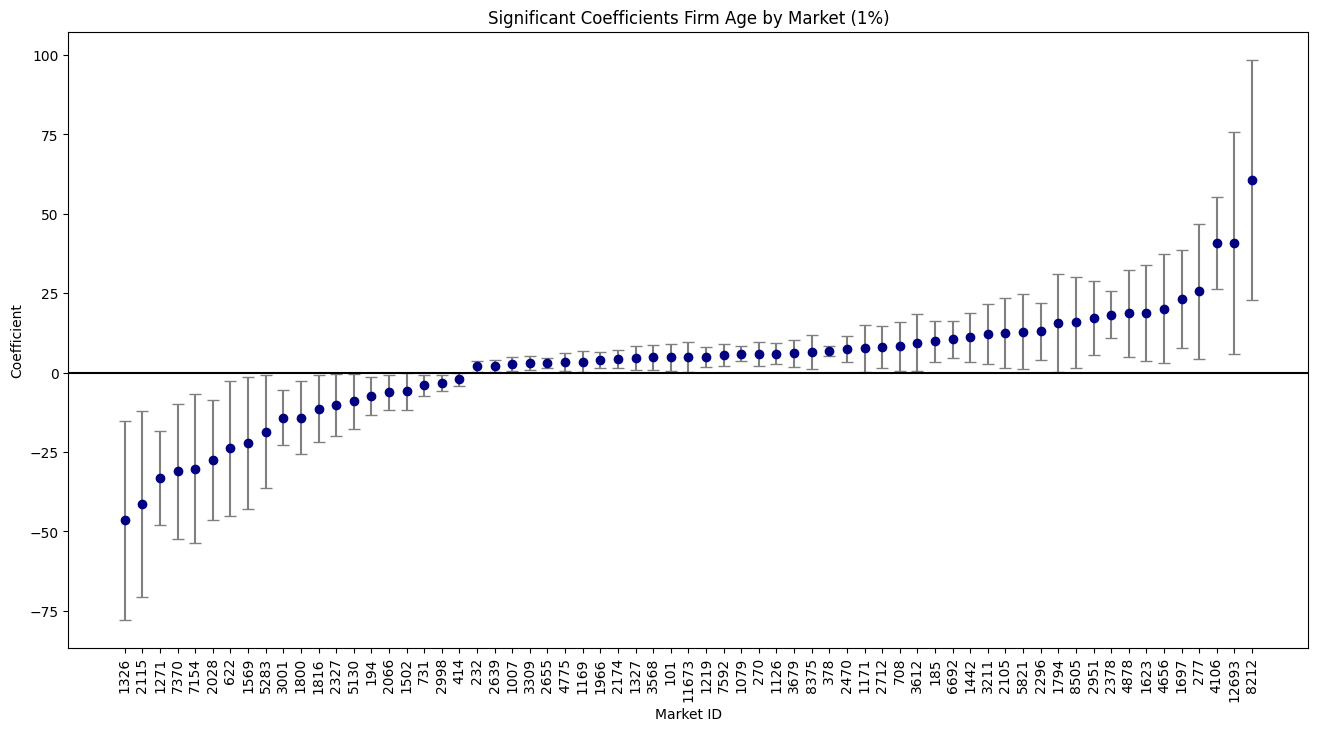

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

# Rename columns if needed to match the example
df_age = df_age.rename(columns={' Market Item': 'market_id', ' Coefficient': 'coefficient', ' Std. Error': 'std_error', ' Sig_1pct': 'sig_1pct', ' Sig_5pct': 'sig_5pct', ' Sig_10pct': 'sig_10pct'})
df_age = df_age[df_age['market_id'] != 4500]

# Filter rows for significant coefficients (assuming 'sig_1pct' indicates significance)
df_significant_age = df_age[df_age['sig_1pct'] == 1]

# Sort the dataframe by 'coefficient' in ascending order
df_significant_age = df_significant_age.sort_values(by='coefficient', ascending=True)

# Calculate 95% confidence intervals
ci_95 = df_significant_age['std_error'] * 2.54

# Plot the coefficients with error bars
plt.figure(figsize=(16, 8))
plt.errorbar(range(len(df_significant_age)), df_significant_age['coefficient'],  # Use range of sorted index for evenly spaced ticks
             yerr=ci_95, fmt='o', color='navy', 
             ecolor='gray', capsize=4)

# Add a vertical line at y=0
plt.axhline(y=0, color='black')

# Labels and title
plt.xlabel('Market ID')
plt.ylabel('Coefficient')
plt.title('Significant Coefficients Firm Age by Market (1%)')

# Set the x-ticks to correspond to the sorted market_id values
plt.xticks(range(len(df_significant_age)), df_significant_age['market_id'].astype(int), rotation=90)

# Save the plot as a .pdf file (optional)
plt.savefig('/Users/dvacchini/Library/CloudStorage/Dropbox/Projects_Brazilian_data/Dario_vacchini/output/graphs/coef_sig_age_market_1pct.pdf', bbox_inches='tight', dpi=300)

plt.show()

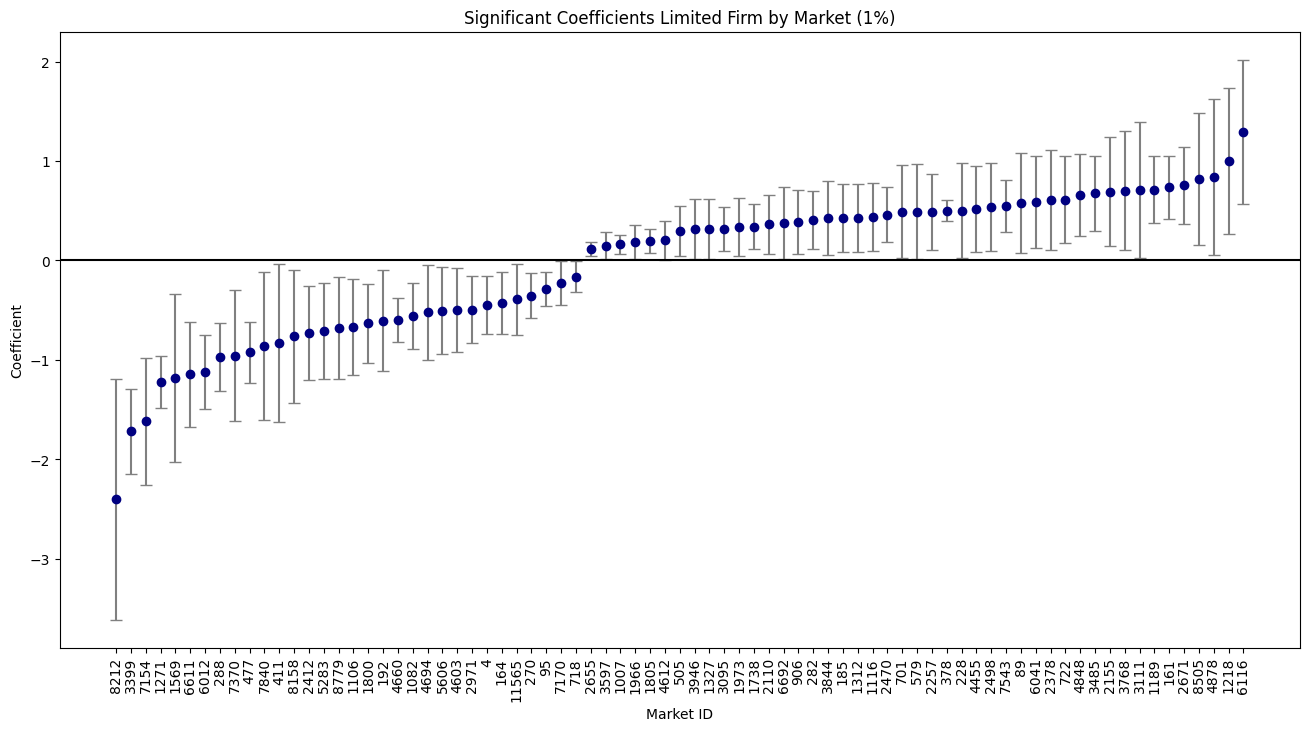

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

# Rename columns if needed to match the example
df_lim_firm = df_lim_firm.rename(columns={' Market Item': 'market_id', ' Coefficient': 'coefficient', ' Std. Error': 'std_error', ' Sig_1pct': 'sig_1pct', ' Sig_5pct': 'sig_5pct', ' Sig_10pct': 'sig_10pct'})
df_lim_firm = df_lim_firm[df_lim_firm['market_id'] != 4500]

# Filter rows for significant coefficients (assuming 'sig_1pct' indicates significance)
df_significant_lim = df_lim_firm[df_lim_firm['sig_1pct'] == 1]

# Sort the dataframe by 'coefficient' in ascending order
df_significant_lim = df_significant_lim.sort_values(by='coefficient', ascending=True)

# Calculate 95% confidence intervals
ci_95 = df_significant_lim['std_error'] * 2.54

# Plot the coefficients with error bars
plt.figure(figsize=(16, 8))
plt.errorbar(range(len(df_significant_lim)), df_significant_lim['coefficient'],  # Use range of sorted index for evenly spaced ticks
             yerr=ci_95, fmt='o', color='navy', 
             ecolor='gray', capsize=4)

# Add a vertical line at y=0
plt.axhline(y=0, color='black')

# Labels and title
plt.xlabel('Market ID')
plt.ylabel('Coefficient')
plt.title('Significant Coefficients Limited Firm by Market (1%)')

# Set the x-ticks to correspond to the sorted market_id values
plt.xticks(range(len(df_significant_lim)), df_significant_lim['market_id'].astype(int), rotation=90)

# Save the plot as a .pdf file (optional)
plt.savefig('/Users/dvacchini/Library/CloudStorage/Dropbox/Projects_Brazilian_data/Dario_vacchini/output/graphs/coef_sig_limited_firm_market_1pct.pdf', bbox_inches='tight', dpi=300)

plt.show()

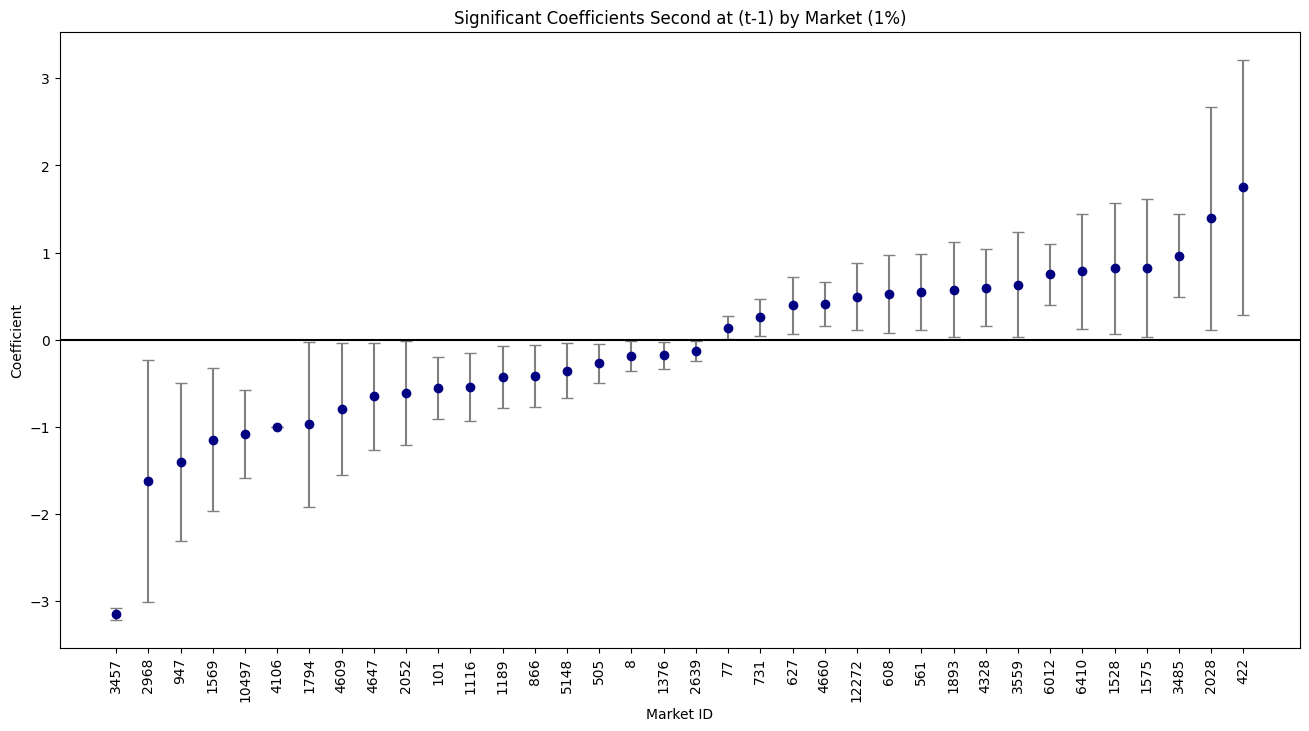

In [22]:
import pandas as pd
import matplotlib.pyplot as plt

# Rename columns if needed to match the example
df_sec_bid = df_sec_bid.rename(columns={' Market Item': 'market_id', ' Coefficient': 'coefficient', ' Std. Error': 'std_error', ' Sig_1pct': 'sig_1pct', ' Sig_5pct': 'sig_5pct', ' Sig_10pct': 'sig_10pct'})
df_sec_bid = df_sec_bid[df_sec_bid['market_id'] != 2951]

# Filter rows for significant coefficients (assuming 'sig_1pct' indicates significance)
df_significant_sec = df_sec_bid[df_sec_bid['sig_1pct'] == 1]

# Sort the dataframe by 'coefficient' in ascending order
df_significant_sec = df_significant_sec.sort_values(by='coefficient', ascending=True)

# Calculate 95% confidence intervals
ci_95 = df_significant_sec['std_error'] * 2.54

# Plot the coefficients with error bars
plt.figure(figsize=(16, 8))
plt.errorbar(range(len(df_significant_sec)), df_significant_sec['coefficient'],  # Use range of sorted index for evenly spaced ticks
             yerr=ci_95, fmt='o', color='navy', 
             ecolor='gray', capsize=4)

# Add a vertical line at y=0
plt.axhline(y=0, color='black')

# Labels and title
plt.xlabel('Market ID')
plt.ylabel('Coefficient')
plt.title('Significant Coefficients Second at (t-1) by Market (1%)')

# Set the x-ticks to correspond to the sorted market_id values
plt.xticks(range(len(df_significant_sec)), df_significant_sec['market_id'].astype(int), rotation=90)

# Save the plot as a .pdf file (optional)
plt.savefig('/Users/dvacchini/Library/CloudStorage/Dropbox/Projects_Brazilian_data/Dario_vacchini/output/graphs/coef_sig_second_t_minus_1_market_1pct.pdf', bbox_inches='tight', dpi=300)

plt.show()

In [23]:
# Positive coefficient for market - sig: 0.01

positive_significant_markets_won_1 = df_won[(df_won['sig_1pct']==1) & (df_won['coefficient'] > 0)]['market_id'].tolist()
print("won_t_minus_1 (0.01):", positive_significant_markets_won_1)

positive_significant_markets_last_1 = df_last[(df_last['sig_1pct']==1) & (df_last['coefficient'] > 0)]['market_id'].tolist()
print("last (0.01):", positive_significant_markets_last_1)

positive_significant_markets_age_1 = df_age[(df_age['sig_1pct']==1) & (df_age['coefficient'] > 0)]['market_id'].astype(int).to_list()
print("age (0.01):", positive_significant_markets_age_1)

positive_significant_markets_lim_1 = df_lim_firm[(df_lim_firm['sig_1pct']==1) & (df_lim_firm['coefficient'] > 0)]['market_id'].astype(int).to_list()
print("limited_firm (0.01):", positive_significant_markets_lim_1)

positive_significant_markets_sec_1 = df_sec_bid[(df_sec_bid['sig_1pct']==1) & (df_sec_bid['coefficient'] > 0)]['market_id'].astype(int).to_list()
print("second_t_minus_1 (0.01):", positive_significant_markets_sec_1)

positive_significant_markets_90won_1 = df_90won[(df_90won['sig_1pct']==1) & (df_90won['coefficient'] > 0)]['market_id'].tolist()
print("90-Day Share of firm participation (0.01):", positive_significant_markets_90won_1)

won_t_minus_1 (0.01): [20, 505, 903, 946, 1189, 1288, 1376, 1569, 1794, 1816, 2370, 2778, 2951, 3309, 3385, 3399, 3593, 3596, 3612, 4106, 6611, 6736, 10497]
last (0.01): [4, 95, 292, 378, 468, 477, 708, 1058, 1082, 1376, 2037, 2088, 2134, 2228, 2401, 2412, 2599, 2973, 3124, 3309, 3462, 3593, 3597, 3687, 3728, 3844, 4597, 4694, 7370, 7592, 10497]
age (0.01): [101, 185, 232, 270, 277, 378, 708, 1007, 1079, 1126, 1169, 1171, 1219, 1327, 1442, 1623, 1697, 1794, 1966, 2105, 2174, 2296, 2378, 2470, 2639, 2655, 2712, 2951, 3211, 3309, 3568, 3612, 3679, 4106, 4656, 4775, 4878, 5821, 6692, 7592, 8212, 8375, 8505, 11673, 12693]
limited_firm (0.01): [89, 161, 185, 228, 282, 378, 505, 579, 701, 722, 906, 1007, 1116, 1189, 1218, 1312, 1327, 1738, 1805, 1966, 1973, 2110, 2155, 2257, 2378, 2470, 2498, 2655, 2671, 3095, 3111, 3485, 3597, 3768, 3844, 3946, 4455, 4612, 4848, 4878, 6041, 6116, 6692, 7543, 8505]
second_t_minus_1 (0.01): [77, 422, 561, 608, 627, 731, 1528, 1575, 1893, 2028, 3485, 3559, 432

In [24]:
# Positive coefficient for market - sig: 0.05

positive_significant_markets_won_5 = df_won[(df_won['sig_5pct']==1) & (df_won['coefficient'] > 0)]['market_id'].tolist()
print("won_t_minus_1 (0.05):", positive_significant_markets_won_5)

positive_significant_markets_last_5 = df_last[(df_last['sig_5pct']==1) & (df_last['coefficient'] > 0)]['market_id'].tolist()
print("last (0.05):", positive_significant_markets_last_5)

positive_significant_markets_age_5 = df_age[(df_age['sig_5pct']==1) & (df_age['coefficient'] > 0)]['market_id'].astype(int).to_list()
print("age (0.05):", positive_significant_markets_age_5)

positive_significant_markets_lim_5 = df_lim_firm[(df_lim_firm['sig_5pct']==1) & (df_lim_firm['coefficient'] > 0)]['market_id'].astype(int).to_list()
print("limited_firm (0.05):", positive_significant_markets_lim_5)

positive_significant_markets_90won_5 = df_90won[(df_90won['sig_5pct']==1) & (df_90won['coefficient'] > 0)]['market_id'].tolist()
print("90-Day Share of firm participation (0.05):", positive_significant_markets_90won_5)

won_t_minus_1 (0.05): [20, 86, 389, 435, 505, 815, 866, 903, 946, 1058, 1079, 1116, 1171, 1189, 1288, 1376, 1569, 1623, 1740, 1761, 1794, 1816, 2052, 2155, 2370, 2590, 2639, 2778, 2816, 2951, 2998, 3307, 3309, 3385, 3399, 3593, 3596, 3612, 4079, 4106, 4462, 4609, 6611, 6736, 8779, 10497]
last (0.05): [4, 20, 93, 95, 194, 288, 292, 329, 363, 378, 468, 477, 708, 1007, 1028, 1058, 1082, 1102, 1226, 1327, 1376, 1536, 1583, 1609, 1636, 1728, 1816, 2037, 2088, 2134, 2206, 2228, 2378, 2401, 2412, 2498, 2599, 2778, 2789, 2895, 2973, 3054, 3124, 3309, 3314, 3407, 3462, 3555, 3568, 3592, 3593, 3597, 3687, 3728, 3844, 4204, 4455, 4597, 4612, 4647, 4694, 4848, 5443, 6029, 6288, 7370, 7592, 10497]
age (0.05): [101, 184, 185, 228, 232, 270, 277, 345, 378, 499, 573, 574, 691, 708, 712, 741, 746, 867, 885, 1007, 1029, 1079, 1126, 1169, 1171, 1218, 1219, 1226, 1302, 1327, 1442, 1623, 1697, 1792, 1794, 1884, 1966, 2088, 2105, 2174, 2296, 2329, 2378, 2399, 2470, 2570, 2639, 2655, 2712, 2920, 2951, 3052, 

In [25]:
# Positive coefficient for market - sig: 0.10

positive_significant_markets_won_10 = df_won[(df_won['sig_10pct']==1) & (df_won['coefficient'] > 0)]['market_id'].tolist()
print("won_t_minus_1 (0.10):", positive_significant_markets_won_10)

positive_significant_markets_last_10 = df_last[(df_last['sig_10pct']==1) & (df_last['coefficient'] > 0)]['market_id'].tolist()
print("last (0.10):", positive_significant_markets_last_10)

positive_significant_markets_age_10 = df_age[(df_age['sig_10pct']==1) & (df_age['coefficient'] > 0)]['market_id'].astype(int).to_list()
print("age (0.10):", positive_significant_markets_age_10)

positive_significant_markets_lim_10 = df_lim_firm[(df_lim_firm['sig_10pct']==1) & (df_lim_firm['coefficient'] > 0)]['market_id'].astype(int).to_list()
print("limited_firm (0.10):", positive_significant_markets_lim_10)

won_t_minus_1 (0.10): [8, 20, 86, 139, 389, 435, 464, 505, 722, 815, 866, 903, 946, 954, 1058, 1079, 1116, 1171, 1189, 1288, 1376, 1569, 1623, 1740, 1761, 1794, 1816, 1871, 1903, 2052, 2107, 2155, 2370, 2590, 2603, 2639, 2642, 2671, 2778, 2816, 2919, 2951, 2998, 3307, 3309, 3385, 3399, 3567, 3593, 3596, 3612, 3621, 3866, 4079, 4106, 4233, 4411, 4462, 4609, 6611, 6736, 7370, 8779, 9783, 10497]
last (0.10): [4, 20, 86, 93, 95, 194, 288, 292, 298, 329, 363, 378, 458, 468, 477, 708, 885, 887, 971, 981, 1007, 1028, 1058, 1082, 1102, 1157, 1163, 1226, 1327, 1376, 1465, 1494, 1536, 1583, 1609, 1636, 1728, 1781, 1795, 1816, 1966, 2037, 2088, 2098, 2107, 2115, 2134, 2206, 2228, 2378, 2401, 2412, 2498, 2599, 2603, 2661, 2778, 2789, 2895, 2973, 3054, 3095, 3124, 3183, 3309, 3314, 3407, 3462, 3474, 3555, 3568, 3592, 3593, 3597, 3600, 3670, 3687, 3728, 3783, 3844, 4204, 4455, 4597, 4612, 4647, 4694, 4837, 4848, 4866, 5443, 6029, 6041, 6288, 6611, 7370, 7592, 10497]
age (0.10): [89, 93, 101, 184, 18

In [26]:
# Common market -- sig: 0.01 

won_t_minus_1_age_1 = list(set(positive_significant_markets_won_1) & set(positive_significant_markets_age_1))
print("won_t_minus_1 - age (0.01):", won_t_minus_1_age_1)

won_t_minus_1_limited_firm_1 = list(set(positive_significant_markets_won_1) & set(positive_significant_markets_lim_1))
print("won_t_minus_1 - limited_firm (0.01):", won_t_minus_1_limited_firm_1)

last_age_1 = list(set(positive_significant_markets_last_1) & set(positive_significant_markets_age_1))
print("last - age (0.01):", last_age_1)

last_limited_firm_1 = list(set(positive_significant_markets_last_1) & set(positive_significant_markets_lim_1))
print("last - limited_firm (0.01):", last_limited_firm_1)

won_t_minus_1_last_1 = list(set(positive_significant_markets_won_1) & set(positive_significant_markets_last_1))
print("won_t_minus_1 - last (0.01):", won_t_minus_1_last_1)

won_t_minus_1 - age (0.01): [1794, 2951, 4106, 3309, 3612]
won_t_minus_1 - limited_firm (0.01): [505, 1189]
last - age (0.01): [7592, 378, 708, 3309]
last - limited_firm (0.01): [378, 3844, 3597]
won_t_minus_1 - last (0.01): [1376, 10497, 3309, 3593]


In [27]:
# Common market -- sig: 0.05

won_t_minus_1_age_5 = list(set(positive_significant_markets_won_5) & set(positive_significant_markets_age_5))
print("won_t_minus_1 - age (0.05):", won_t_minus_1_age_5)

won_t_minus_1_limited_firm_5 = list(set(positive_significant_markets_won_5) & set(positive_significant_markets_lim_5))
print("won_t_minus_1 - limited_firm (0.05):", won_t_minus_1_limited_firm_5)

last_age_5 = list(set(positive_significant_markets_last_5) & set(positive_significant_markets_age_5))
print("last - limited_firm (0.05):", last_age_5)

last_limited_firm_5 = list(set(positive_significant_markets_last_5) & set(positive_significant_markets_lim_5))
print("last - limited_firm (0.05):", last_limited_firm_5)

won_t_minnus_1_last_limited_firm_5 = list(set(positive_significant_markets_last_5) & set(positive_significant_markets_lim_5) & set(positive_significant_markets_won_5))
print("won_t_minnus_1 - last - limited_firm (0.05):", won_t_minnus_1_last_limited_firm_5)

won_t_minus_1 - age (0.05): [1794, 1623, 2951, 4106, 3309, 2639, 1171, 6611, 1079, 3612]
won_t_minus_1 - limited_firm (0.05): [4609, 10497, 1189, 2155, 1116, 2998, 505, 3612]
last - limited_firm (0.05): [708, 3687, 2088, 7592, 1226, 2378, 3309, 1327, 1007, 3568, 4848, 378]
last - limited_firm (0.05): [10497, 2498, 3844, 4612, 4455, 1609, 2378, 3597, 1327, 1007, 4848, 378]
won_t_minnus_1 - last - limited_firm (0.05): [10497]


In [28]:
# Common market -- sig: 0.10

won_t_minus_1_age_10 = list(set(positive_significant_markets_won_10) & set(positive_significant_markets_age_10))
print("won_t_minus_1 - age (0.10):", won_t_minus_1_age_10)

won_t_minus_1_limited_firm_10 = list(set(positive_significant_markets_won_10) & set(positive_significant_markets_lim_10))
print("won_t_minus_1 - limited_firm (0.10):", won_t_minus_1_limited_firm_10)

last_age_10 = list(set(positive_significant_markets_last_10) & set(positive_significant_markets_age_10))
print("last - limited_firm (0.10):", last_age_10)

last_limited_firm_10 = list(set(positive_significant_markets_last_10) & set(positive_significant_markets_lim_10))
print("last - limited_firm (0.10):", last_limited_firm_10)

won_t_minus_1 - age (0.10): [10497, 1794, 2370, 389, 9783, 2951, 1623, 4106, 3309, 2639, 1171, 6611, 1079, 4411, 3612]
won_t_minus_1 - limited_firm (0.10): [4609, 10497, 1189, 903, 2155, 1116, 2671, 722, 2998, 505, 3612]
last - limited_firm (0.10): [10497, 3844, 2088, 7592, 1966, 1327, 708, 1226, 2378, 971, 6611, 93, 3687, 3309, 1007, 4848, 3568, 885, 378]
last - limited_firm (0.10): [10497, 4612, 1157, 3844, 3597, 3095, 6041, 1966, 1327, 2498, 2115, 1609, 2378, 1494, 4455, 363, 1007, 4848, 378]
